<a href="https://colab.research.google.com/github/alyPoint/CEFET---Processamento-de-Sinais-I-140826/blob/main/DSP_1_PRATICA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pratica 2 exercício 1


 Gráfico de 500 Hz 



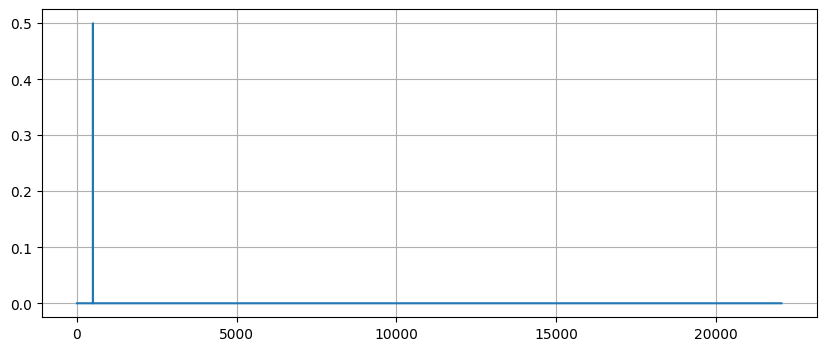


 Gráfico de 1000 Hz 



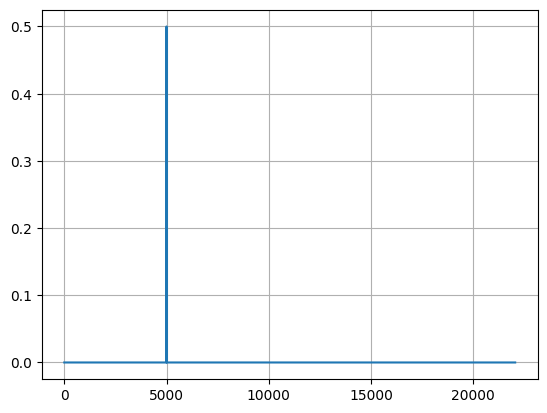


 Gráfico de 10000 Hz 



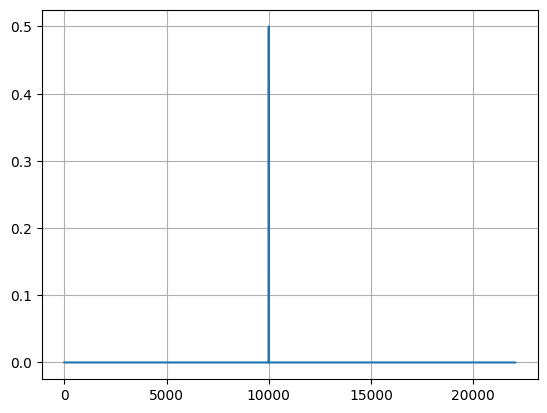


 Gráfico de 50000 Hz 



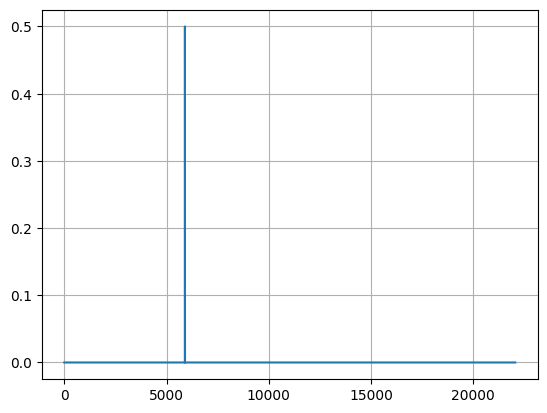

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.signal as signal

#período com frequência de amostragem
t = 1/44100

#frequência_cosseno = 500
#frequência_amostragem = 44.1 kHz
#duração = 1.0

arr = np.arange (0, 1, t, dtype = None)
xA = np.cos(2 * np.pi * 500 * arr)
xB = np.cos(2 * np.pi * 5000 * arr)
xC = np.cos(2 * np.pi * 10000 * arr)
xD = np.cos(2 * np.pi * 50000 * arr)

frequenciasA, espectroA = signal.periodogram(xA, 44100)
frequenciasB, espectroB = signal.periodogram(xB, 44100)
frequenciasC, espectroC = signal.periodogram(xC, 44100)
frequenciasD, espectroD = signal.periodogram(xD, 44100)

plt.figure(figsize = (10,4))

print("\n Gráfico de 500 Hz \n")
plt.plot(frequenciasA, espectroA)

plt.grid(True)
plt.show()

print("\n Gráfico de 1000 Hz \n")
plt.plot(frequenciasB, espectroB)

plt.grid(True)
plt.show()

print("\n Gráfico de 10000 Hz \n")
plt.plot(frequenciasC, espectroC)

plt.grid(True)
plt.show()

print("\n Gráfico de 50000 Hz \n")
plt.plot(frequenciasD, espectroD)

plt.grid(True)
plt.show()

Pratica 2 exercicio 2

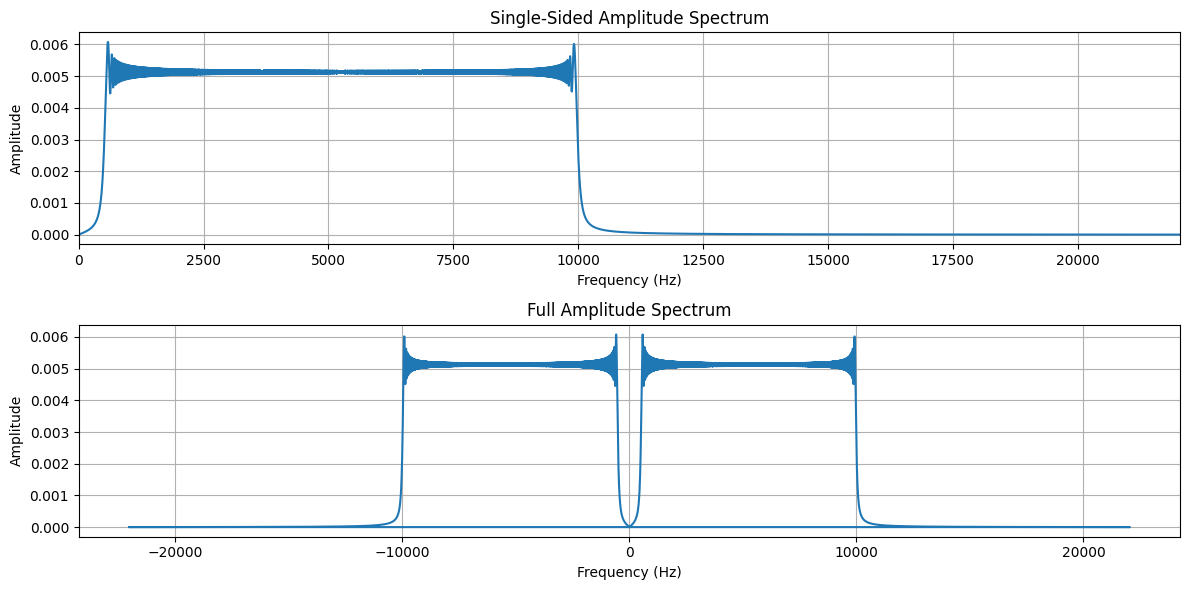

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.fft import fft, fftfreq


fs = 44100                                                           # Frequência de amostragem

# nome do intervalo = np.arange(inicio, fim, passo)
t = np.arange(0, 1, 1/fs)                                            # Intervalo de tempo e amostragem

# nome do sinal = chirp(intervalo de tempo, frequencia inicial, tempo final, frequencia final, método)
sinal = chirp(t, 500, 1, 10000, method = 'linear')

def calculate_spectrum(signal, frequency_sample, single_sided=True):
    N = len(signal) # Number of sample points
    T = 1.0 / 44100 # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

#0 a 10000
frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(sinal, fs, single_sided=True)

#-10000 a 10000
frequencies_full, amplitudes_full = calculate_spectrum(sinal, fs, single_sided=False)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, fs / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()